In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

load_dotenv()
warnings.filterwarnings('ignore')

c:\Users\vitor\Data_Projects\EC2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
CONNECT_STRING = '(description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))(connect_data=(service_name=g253a13c6f2211a_dadosaiopslocaweb_low.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))'

def conectar_oracle():
    return oracledb.connect(
        user=DB_USER,
        password=DB_PASSWORD,
        dsn=CONNECT_STRING,
        wallet_location=r"C:/opt/OracleCloud/Wallet_dadosAIOpsLocaweb",
        wallet_password=DB_PASSWORD
    )

# Ler dados de uma view do banco de dados oracle
df = pd.read_sql_query("SELECT * FROM admin.TB_INCIDENTES_LOCAWEB", con=conectar_oracle())

In [2]:
df = pd.read_csv('fast_dataset')

In [3]:
df.shape

(122543, 21)

In [4]:
df.sample(50)

,Unnamed: 0.1,Unnamed: 0,CD_INCIDENTE,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,...,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
122348,122348,122348,INC8260903,4 - Baixa,khhc,cat71,sub216,Team14,IC04860,2025-01-09 05:12:55,...,2025-01-14 01:00:21,8522,Falha de Cloud,Problem: IC06745 - IC01442 - Servers with Hype...,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,NAO,NAO
8487,8487,8487,INC8640214,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00184,2025-12-20 04:15:28,...,2025-12-20 04:27:52,744,Em andamento,Problem: Disk I/O is overloaded on IC00184,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
13088,13088,13088,INC8635187,4 - Baixa,lcem,cat76,sub11,Team05,IC00404,2025-12-16 12:28:25,...,2025-12-16 14:20:03,498,Falha causada pelo cliente,[AEP] Serviço está desativado.,Definitiva,Manual,NaN,Encerrado,NAO,NAO
52857,52857,52857,INC8581714,2 - Alta,lhvp,cat73,sub7,Team14,IC01355,2025-10-27 09:35:29,...,2025-10-27 09:43:42,370,Falha de Sistema Operacional,Problem: Check: HTTP Type: tcp on Port: 80 Not...,Contorno,Monitoramento,NaN,Encerrado,SIM,NAO
83104,83104,83104,INC8539638,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00174,2025-09-19 19:53:24,...,2025-09-19 21:03:40,4216,Em andamento,Problem: Free disk space is less than 10% on v...,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
40406,40406,40406,INC8603194,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00511,2025-11-17 14:41:21,...,2025-11-17 14:41:58,37,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
25197,25197,25197,INC8618237,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00112,2025-12-01 12:55:16,...,2025-12-01 12:59:09,233,Em andamento,Problem: Disk I/O is overloaded on IC00112,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
10162,10162,10162,INC8640991,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00016,2025-12-20 22:42:53,...,2025-12-20 22:44:03,70,Em andamento,Problem: Disk I/O is overloaded on IC00016,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
63258,63258,63258,INC8559809,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00367,2025-10-07 23:10:13,...,2025-10-07 23:25:46,933,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
78423,78423,78423,INC8545836,3 - Média,lhvp,cat73,sub87,Team11,IC01446,2025-09-24 16:39:26,...,2025-09-29 01:01:19,1437,Falha de Aplicação,[IC06647] domínio travado em instalação,Contorno,Manual,NaN,Encerrado Automaticamente,SIM,NAO


In [5]:
print(df['DT_ABERTO'].min())
print("\n",df['DT_ABERTO'].max())


2023-01-02 20:19:58

 2025-12-31 23:45:18


In [6]:
df.to_csv('fast_dataset', index=False)

In [7]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CD_INCIDENTE', 'TP_PRIORIDADE',
       'NM_PRODUTO', 'NM_CATEGORIA', 'NM_SUBCATEGORIA', 'NM_GRUPO_DESIGNADO',
       'NM_ITEM_CONFIGURACAO', 'DT_ABERTO', 'DT_RESOLVIDO', 'DT_ENCERRADO',
       'NR_DURACAO', 'CD_FECHAMENTO', 'DS_RESUMIDA', 'TP_SOLUCAO',
       'TP_ABERTO_POR', 'CD_INCIDENTE_PAI', 'TP_STATUS', 'FL_KPI',
       'FL_KPI_VIOLADO'],
      dtype='str')

In [8]:
df.isna().sum()

Unnamed: 0.1                 0
Unnamed: 0                   0
CD_INCIDENTE                 0
TP_PRIORIDADE                0
NM_PRODUTO                   0
NM_CATEGORIA                 0
NM_SUBCATEGORIA              0
NM_GRUPO_DESIGNADO           0
NM_ITEM_CONFIGURACAO         0
DT_ABERTO                    0
DT_RESOLVIDO             82302
DT_ENCERRADO                 0
NR_DURACAO                   0
CD_FECHAMENTO                0
DS_RESUMIDA                  0
TP_SOLUCAO                   0
TP_ABERTO_POR                0
CD_INCIDENTE_PAI        107416
TP_STATUS                    0
FL_KPI                       0
FL_KPI_VIOLADO               0
dtype: int64

In [9]:
df['TP_PRIORIDADE'].value_counts()

TP_PRIORIDADE
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

In [10]:
df.dtypes

Unnamed: 0.1            int64
Unnamed: 0              int64
CD_INCIDENTE              str
TP_PRIORIDADE             str
NM_PRODUTO                str
NM_CATEGORIA              str
NM_SUBCATEGORIA           str
NM_GRUPO_DESIGNADO        str
NM_ITEM_CONFIGURACAO      str
DT_ABERTO                 str
DT_RESOLVIDO              str
DT_ENCERRADO              str
NR_DURACAO              int64
CD_FECHAMENTO             str
DS_RESUMIDA               str
TP_SOLUCAO                str
TP_ABERTO_POR             str
CD_INCIDENTE_PAI          str
TP_STATUS                 str
FL_KPI                    str
FL_KPI_VIOLADO            str
dtype: object

In [11]:
df['DT_ABERTO'] = pd.to_datetime(df['DT_ABERTO'])
df['DT_ENCERRADO'] = pd.to_datetime(df['DT_ENCERRADO'])
df['DT_RESOLVIDO'] = pd.to_datetime(df['DT_RESOLVIDO'])

In [12]:
incidentes_dia = df.groupby(df['DT_ABERTO'].dt.date)['TP_PRIORIDADE'].count()

In [13]:
incidentes_dia

DT_ABERTO
2023-01-02       1
2023-01-09       1
2023-01-11       2
2023-01-16       1
2023-01-17       2
              ... 
2025-12-27    1027
2025-12-28     829
2025-12-29     921
2025-12-30     866
2025-12-31     755
Name: TP_PRIORIDADE, Length: 644, dtype: int64

In [14]:
print(f"A quantidade de dias no dataset é de: {df['DT_ABERTO'].dt.date.max() - df['DT_ABERTO'].dt.date.min()}, \
      \ndata inicial: {df['DT_ABERTO'].dt.date.min()} \
      \ndata final: {df['DT_ABERTO'].dt.date.max()}")

A quantidade de dias no dataset é de: 1094 days, 0:00:00,       
data inicial: 2023-01-02       
data final: 2025-12-31


## Nem todas as datas estão preenchidas

<Axes: xlabel='DT_ABERTO'>

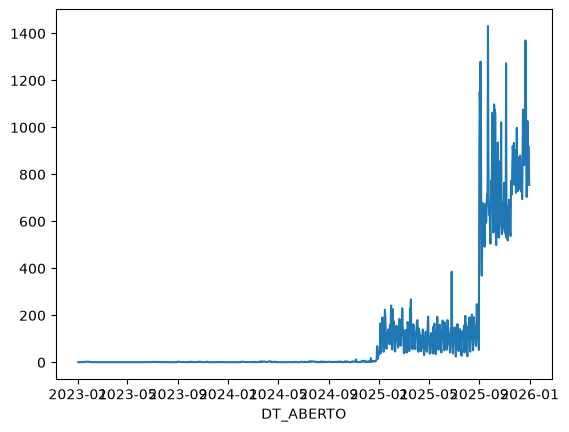

In [15]:
incidentes_dia.plot(legend=False)

## Muito ruído até 2025 

In [16]:
data_limite = pd.to_datetime('2024-12-31')

In [17]:
incidentes_dia = incidentes_dia.reset_index()

In [19]:
incidentes_dia.columns

Index(['DT_ABERTO', 'TP_PRIORIDADE'], dtype='str')

In [20]:
incidentes_dia['DT_ABERTO'] = pd.to_datetime(incidentes_dia['DT_ABERTO']) 

In [22]:
df_filtrado = incidentes_dia[incidentes_dia['DT_ABERTO'] > data_limite]
df_filtrado

,DT_ABERTO,TP_PRIORIDADE
279,2025-01-01,34
280,2025-01-02,55
281,2025-01-03,77
282,2025-01-04,166
283,2025-01-05,39
...,...,...
639,2025-12-27,1027
640,2025-12-28,829
641,2025-12-29,921
642,2025-12-30,866


<Axes: xlabel='DT_ABERTO'>

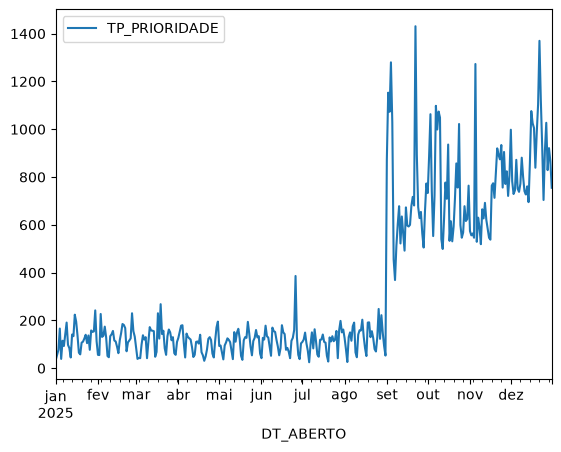

In [26]:
df_filtrado.plot(x ='DT_ABERTO',y='TP_PRIORIDADE')

# Será que os valores de 2023-2024 não tem valor algum? Verificar os que violaram KPI, se existir.